# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
## **Actividad Individual Semana 9: Pronósticos con Series de Tiempo**


#### **Nombre: José Eduardo De Moraes López**
#### **Matrícula: A01634782**

In [4]:
## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

In [5]:
import kagglehub
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import math
from prophet import Prophet
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import keras
from keras import Sequential
from keras import layers
from keras.layers import LSTM, Dense
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Download latest version
path = kagglehub.dataset_download("piyushagni5/monthly-sales-of-french-champagne")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/piyushagni5/monthly-sales-of-french-champagne/versions/1


In [6]:
df = pd.read_csv(path + "/monthly_champagne_sales.csv")
df.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   105 non-null    object
 1   Sales   105 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [8]:
df.columns = ['ds', 'y']
df['ds']= pd.to_datetime(df['ds'])

df.head()

,ds,y
0,1964-01-01,2815
1,1964-02-01,2672
2,1964-03-01,2755
3,1964-04-01,2721
4,1964-05-01,2946


In [9]:
df_temp = df.copy()
df_temp.set_index('ds', inplace=True)
df_temp


,y
ds,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946
...,...
1972-05-01,4618
1972-06-01,5312
1972-07-01,4298


In [10]:
print(df.shape)
print(df_temp.shape)

(105, 2)
(105, 1)


In [11]:
df_temp.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='ds', length=105, freq=None)

In [12]:
df_temp.index.freq = 'MS'  # MS-Month-start-frequency o M=ME-Month-end-frequency

df_temp.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='ds', length=105, freq='MS')

In [13]:
train = df_temp.iloc[0:-12,:]

test = df_temp.iloc[-12:,:]

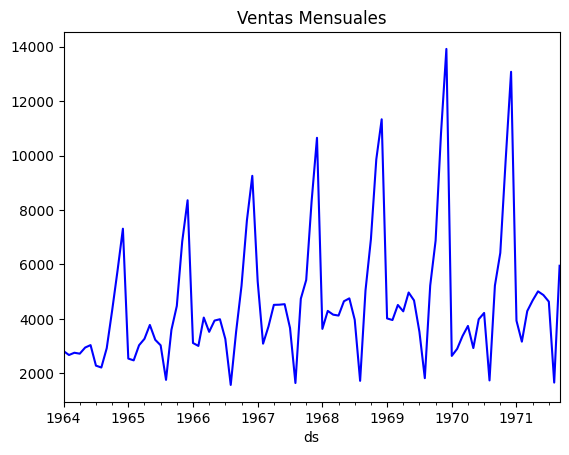

In [14]:
train['y'].plot(title='Ventas Mensuales', style='-b')
plt.show()

# **1 - Modelo ingenuo (Baseline / Persistance / Naive model)**

In [15]:
history = [x for x in train['y'].values]   # Definimos "history" donde de manera incremental se irán agregando registros mensuales.
predictions = list()    # Lista que contendrá las predicciones del modelo ingenuo.

for i in range(len(test['y'])):
  # Obtenemos las predicciones:
  yhat = history[-1]   # La primera vez, tomamos el último dato del Train, en las siguientes, se van agregando los datos de Test.
  predictions.append(yhat)

  # Observaciones-registros reales:
  obs = test.iloc[i]['y']   # Ahora vamos tomando los datos de Test.
  history.append(obs)  # Vamos agregando a "history" (que ya tiene todo los de Train) en cada iteración, un dato más de los de Test.
  print('>Esperado-real = %3d, Predicción = %.3f' % (obs, yhat))


# Calculamos la raíz del error cuadrático medio (RMSE):
rmse1 = np.sqrt(mean_squared_error(test['y'].values, predictions))
print('\nError-Modelo-Naive: RMSE: %.3f' % rmse1)

>Esperado-real = 6981, Predicción = 5951.000
>Esperado-real = 9851, Predicción = 6981.000
>Esperado-real = 12670, Predicción = 9851.000
>Esperado-real = 4348, Predicción = 12670.000
>Esperado-real = 3564, Predicción = 4348.000
>Esperado-real = 4577, Predicción = 3564.000
>Esperado-real = 4788, Predicción = 4577.000
>Esperado-real = 4618, Predicción = 4788.000
>Esperado-real = 5312, Predicción = 4618.000
>Esperado-real = 4298, Predicción = 5312.000
>Esperado-real = 1413, Predicción = 4298.000
>Esperado-real = 5877, Predicción = 1413.000

Error-Modelo-Naive: RMSE: 3135.480


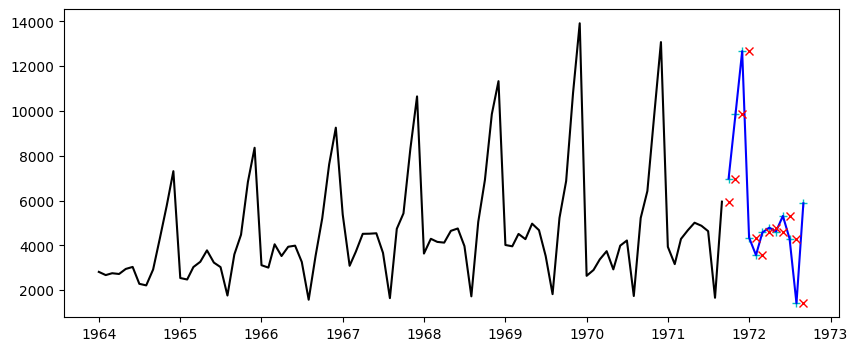

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax = plt.plot(train['y'], '-k')  # Datos de entrenamiento de 1949 a 1959 (los históricos).
ax = plt.plot(test['y'], '+c')    # Datos de prueba reales del año 1960 (los del útimo año a predecir).
ax = plt.plot(test['y'], '-b')
ax = plt.plot(test.index, predictions, 'xr')  # Predicciones del modelo ingenuo para el último año 1960.

# **2 - Modelo ARIMA**

<ipython-input-17-f15937c53dc0>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  decomposition = seasonal_decompose(train['y'].resample('M').mean(), model='multiplicative')  # <<<---- Observa que el modelo es multiplicativo


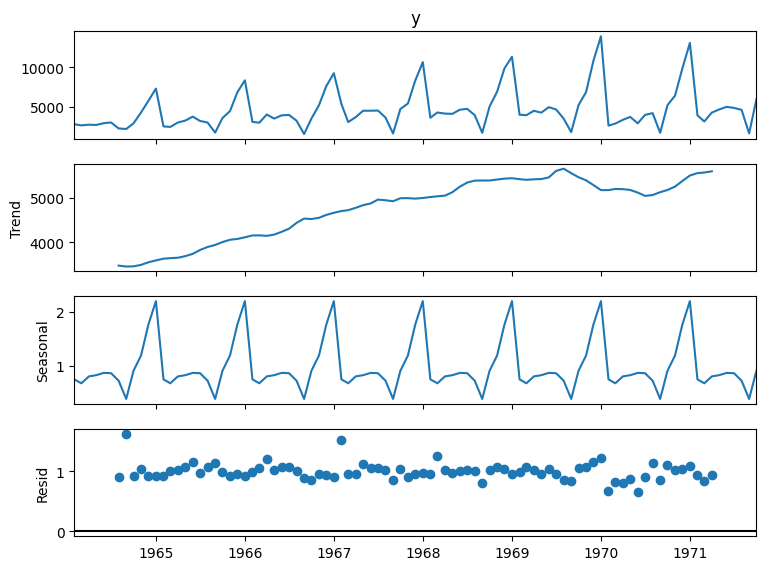

In [17]:
# Gráficos de descomposición estacional:
decomposition = seasonal_decompose(train['y'].resample('M').mean(), model='multiplicative')  # <<<---- Observa que el modelo es multiplicativo
fig = decomposition.plot()
fig.set_size_inches(8,6)
plt.show()

<ipython-input-18-b247bcad148e>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fig = month_plot(train['y'].resample('M').mean(), ylabel='Pasajeros')


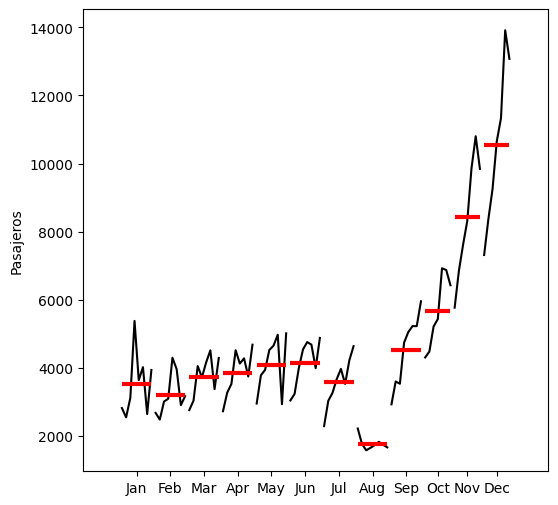

In [18]:
fig = month_plot(train['y'].resample('M').mean(), ylabel='Pasajeros')
fig.set_size_inches(6,6)
plt.show()

<ipython-input-19-ce1ad9285081>:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  fig = quarter_plot(train['y'].resample('Q').mean(), ylabel='Pasajeros')


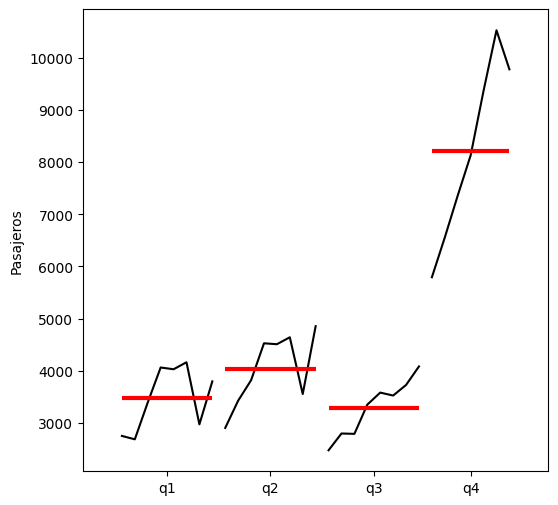

In [19]:
fig = quarter_plot(train['y'].resample('Q').mean(), ylabel='Pasajeros')
fig.set_size_inches(6,6)
plt.show()

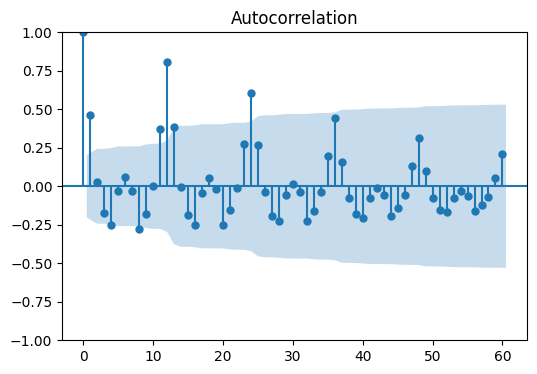

In [20]:
# Gráfico de Autocorrelación (ACF: Auto-Correlation-Function)
fig,ax = plt.subplots(figsize = (6,4))
plot_acf(train['y'], lags=60, ax=ax)   # Eliges el número de unidades (meses) desfasadas. El número de "lags" es el número
plt.show()                          # que define la partición en el eje horizontal. El área no sombreada nos habla de


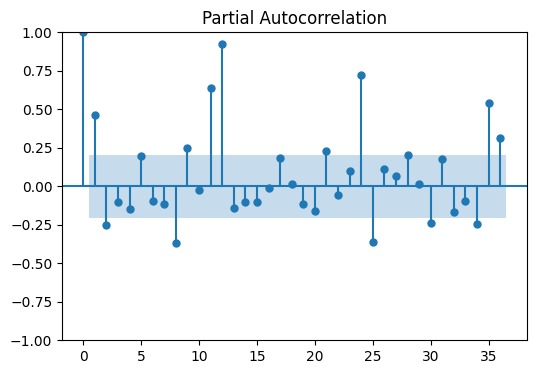

In [21]:
# Gráfico de Autocorrelación Parcial (PACF):
fig, ax = plt.subplots(figsize = (6,4))
plot_pacf(train['y'], lags = 36, ax = ax, method="ols")   # ols: regression of time series on lags of it an on constant. predetrminado method="ywm"
plt.show()

In [22]:
# Lo primero es para quitar la estacionalidad y transformar un problema
# de tipo no-estacionario (SARIMA) en uno estacionario (ARIMA):

# Diferencia de datos consecutivos en el tiempo
# y podemos ahora usar ARIMA:
def difference(dataset, interval=1):
  diff = list()

  for i in range(interval, len(dataset)):
    value = dataset[i] - dataset[i - interval]
    diff.append(value)

  return np.array(diff)



# Invierte las diferencias anteriores, es decir, nos regresa la estacionalidad:
def inverse_difference(history, yhat, interval=1):
  return yhat + history[-interval]

In [23]:
# Definamos la siguiente lista de registros de pasajeros en el tiempo:
history = [x for x in train.loc[:,'y'].values]   # train-ndarray : columna solo con los registros de pasajeros "y".
                               # history-list : lista con los datos del train.

predictions = list()   # Para incluir las predicciones que vaya generando el modelo.

for i in range(len(test['y'])):
  #
  months_in_year = 12
  diff = difference(history, months_in_year)    # diff-list: lista de los datos de diferencias para transformar SARIMA en ARIMA.

  # Generamos el modelo.
  model = ARIMA(diff, order=(3,0,4),) # Si aplicamos diff, entonces d=0 es aplicable.
  model_fit = model.fit(method_kwargs={'maxiter':2000})  # Aumentar las iteraciones para evitar el WarningConvergence.

  yhat = model_fit.forecast()[0]   # prediccions (yhat) de cada registro, es un solo número flotante.
  yhat = inverse_difference(history, yhat, months_in_year)    # El "history" sigue siendo la lista de arriba.
                                                              # El nuevo "yhat" es cada un nuevo valor (float) de predicción.
  predictions.append(yhat)  # predictions-list : lista que se va incrementando al ir agregando cada predicción nueva.

  # Observaciones-reales:
  obs = test.iloc[i]['y']   #  cada dato es un flotante.
  history.append(obs)   #  history-list : se va incrementado a partir del Train con los registros-observaciones reales.

  print('>Esperado-real = %3d, Predicción = %.3f' % (obs, yhat))

# Error RMSE:
rmse2 = np.sqrt(mean_squared_error(test['y'].values, predictions))
print('\nError-Modelo-ARIMA: RMSE: %.3f' % rmse2)

>Esperado-real = 6981, Predicción = 6746.961
>Esperado-real = 9851, Predicción = 9976.050
>Esperado-real = 12670, Predicción = 13375.561
>Esperado-real = 4348, Predicción = 4304.257
>Esperado-real = 3564, Predicción = 3579.288
>Esperado-real = 4577, Predicción = 4427.700
>Esperado-real = 4788, Predicción = 4843.817
>Esperado-real = 4618, Predicción = 5430.794
>Esperado-real = 5312, Predicción = 5337.876
>Esperado-real = 4298, Predicción = 4840.970
>Esperado-real = 1413, Predicción = 1595.940
>Esperado-real = 5877, Predicción = 6004.956

Error-Modelo-ARIMA: RMSE: 365.347


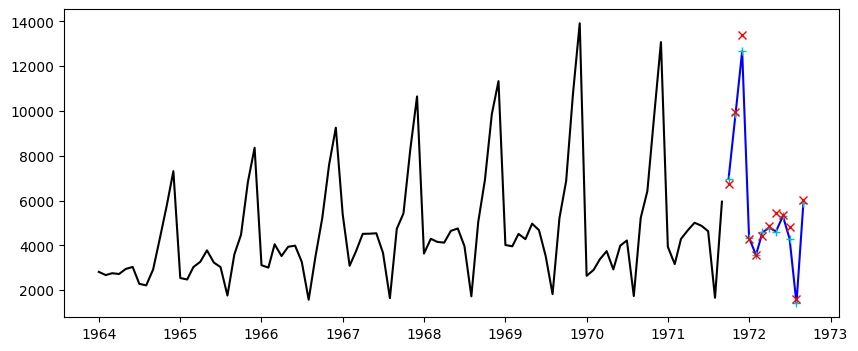

In [24]:
# Veamos su gráfico:
fig, ax = plt.subplots(figsize=(10, 4))
ax = plt.plot(train['y'], '-k')
ax = plt.plot(test['y'], '-b')
ax = plt.plot(test['y'], '+c')
ax = plt.plot(test.index, predictions, 'xr')

# **3 - Modelo Facebook-Meta-Prophet**

In [25]:
train = df.iloc[0:-12,:]
test = df.iloc[-12:,:]

In [26]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=True,
                changepoint_prior_scale=0.1,   # Controla la flexibilidad de la componente Trend, mayor valor mayores fluctuaciones.
                seasonality_prior_scale=18)    # Controla la estacionalidad, mayor el valor, mayor flexibilidad en la estacionalidad.
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9no9o6yn/t4clcw_o.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9no9o6yn/v430v3ne.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94834', 'data', 'file=/tmp/tmp9no9o6yn/t4clcw_o.json', 'init=/tmp/tmp9no9o6yn/v430v3ne.json', 'output', 'file=/tmp/tmp9no9o6yn/prophet_modelycpgx9g8/prophet_model-20250311040256.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:02:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:02:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [27]:
pred_FP = model.predict(test)['yhat']
rmse3 = np.sqrt(mean_squared_error(test['y'], pred_FP))
print('\nError-Modelo-FacebookProphet: RMSE: %.3f' % rmse3)


Error-Modelo-FacebookProphet: RMSE: 462.459


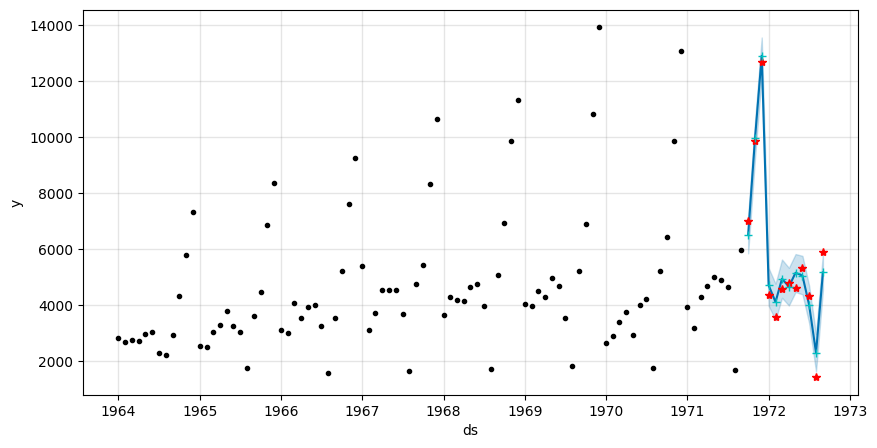

In [28]:
forecast = model.predict(test)

fig, ax = plt.subplots(figsize=(10, 5))
model.plot(forecast, ax=ax)               # Las predicciones se muestran con la línea continua, junto con su región de variabilidad de la predicción.
ax = plt.plot(test['ds'], test['y'], '*r')   # Agregamos los datos de prueba (Test) con puntos rojos, para observar la diferencia.
ax = plt.plot(test['ds'], forecast['yhat'], '+c')    # Valores reales.

# **4 - Long Short Term Memory (LSTM)**

In [29]:
def creamos_secuencias(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])  # Ventana en este ejercicio de 12 meses de manera continua
        y.append(data[i])  # y el siguiente mes a predecir, dados los 12 anteriores.
    return np.array(X), np.array(y)

In [30]:
# Tamaño de la ventana, para este ejercicio de la aerolínea estamos
# considerando 12 meses:

window_size = 12

# Creamos las secuencias de entrenamiento
X, y = creamos_secuencias(df_temp[['y']].values, window_size)

print(X.shape)  # verifiquemos que el formato es el requerido por la CNN.

(93, 12, 1)


In [31]:
# Dividimos los datos en Entrenamiento y Prueba:
split = int(0.85 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape)   # (secuencias, tamaño_secuencia, variables)
print(X_test.shape)

(79, 12, 1)
(14, 12, 1)


In [33]:
seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Construir el modelo
model = Sequential()
model.add(LSTM(150, return_sequences=True, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)))
model.add(Dropout(0.2))
model.add(LSTM(75, return_sequences=False, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compilar el modelo
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 462ms/step - loss: 31806168.0000 - root_mean_squared_error: 5624.0220 - val_loss: 14717499.0000 - val_root_mean_squared_error: 3836.3391
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 12274642.0000 - root_mean_squared_error: 3500.7502 - val_loss: 8057801.0000 - val_root_mean_squared_error: 2838.6265
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 7595173.0000 - root_mean_squared_error: 2755.3230 - val_loss: 7548996.0000 - val_root_mean_squared_error: 2747.5435
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 7141598.5000 - root_mean_squared_error: 2670.1396 - val_loss: 7171240.0000 - val_root_mean_squared_error: 2677.9170
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 6882264.0000 - root_mean_squared_error: 2622.2700 - val_loss: 16169331.0000 - val_root_mean_squared_error: 4021.1106
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 17029266.0000 - root_mean_squared_error: 4122.3408 - val_loss: 7235

In [34]:
pred_LSTM = model.predict(X_test[-12:])
y_test_real = y_test[-12:].reshape(-1, 1)

# Calculamos el RMSE en la escala original de los datos:
rmse4 = np.sqrt(mean_squared_error(y_test_real, pred_LSTM))
print('\nError-Modelo-LTSM: RMSE: %.3f' % rmse4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step

Error-Modelo-FacebookProphet: RMSE: 496.355


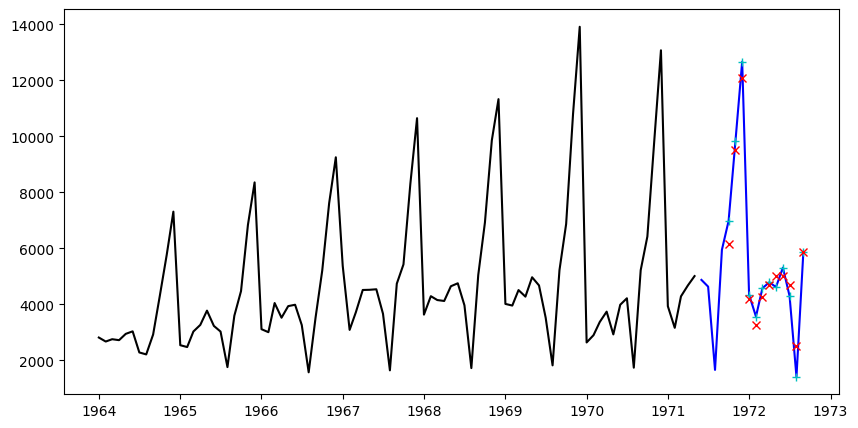

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = plt.plot(df['ds'][0:int(0.85 * len(df))], df['y'][0:int(0.85 * len(df))], '-k')  # Datos de entrenamiento de 1949 a 1959.
ax = plt.plot(df['ds'][int(0.85 * len(df)):], df['y'][int(0.85 * len(df)):], '-b')    # Datos de prueba del año 1960 y un poco mas, dependiendo del tamaño de Test.
ax = plt.plot(df['ds'][-12:], df['y'][-12:], '+c')    # Datos de prueba incluyendo solo los puntuales reales del año 1960.
ax = plt.plot(df['ds'][-12:], pred_LSTM, 'xr')

# **Conclusión**

In [37]:
print(f"Ingenuo/Naive - RMSE: {rmse1:.2f}")
print(f"ARIMA - RMSE: {rmse2:.2f}")
print(f"Facebook Prophet - RMSE: {rmse3:.2f}")
print(f"LSTM - RMSE: {rmse4:.2f}")

Ingenuo/Naive - RMSE: 3135.48
ARIMA - RMSE: 365.35
Facebook Prophet - RMSE: 462.46
LSTM - RMSE: 496.36


Las predicciones basadas en series de tiempo representan una de las aplicaciones más valiosas de la inteligencia artificial en la industria, ya que permiten identificar patrones clave que optimizan procesos críticos como la gestión de ventas e inventarios. En este caso, se exploraron cuatro modelos para predecir las ventas de champán: el modelo ingenuo, ARIMA, Facebook Prophet y LSTM. Cada uno de estos modelos tiene ventajas y desventajas específicas, lo que los hace adecuados para diferentes escenarios.

El modelo ingenuo, aunque simple y rápido de implementar, obtuvo un RMSE de 3135, lo que lo convierte en el menos preciso. Sin embargo, su simplicidad lo hace útil como punto de referencia inicial para comparar la efectividad de modelos más complejos. Por otro lado, el modelo ARIMA demostró ser el más efectivo en este caso, con un RMSE de 365. Su capacidad para capturar tendencias y patrones estacionales, junto con la interacción adecuada de sus hiperparámetros, permitió realizar predicciones más precisas y confiables.

El modelo Facebook Prophet, con un RMSE de 462, mostró un rendimiento sólido, especialmente por su facilidad de uso y su capacidad para manejar estacionalidades y días festivos de manera automática. Sin embargo, en este caso, no superó a ARIMA en precisión. Finalmente, el modelo LSTM, con un RMSE de 496, aunque poderoso para capturar dependencias temporales complejas, requirió un ajuste más cuidadoso de hiperparámetros y recursos computacionales, lo que podría justificar su menor rendimiento en comparación con ARIMA.

En este caso de estudio, el modelo ARIMA destacó como el más efectivo, gracias a su capacidad para interactuar eficientemente con los hiperparámetros y adaptarse a los patrones de los datos. Sin embargo, es importante destacar que todos los modelos presentaron dificultades para alcanzar una precisión absoluta, especialmente durante picos de temporalidad, lo que sugiere que fenómenos extremos o eventos atípicos pueden ser un desafío incluso para los modelos más avanzados.

Este ejercicio fue particularmente interesante debido al volumen de ventas de champán que maneja la compañía, con miles de unidades vendidas mensualmente. Los resultados obtenidos, aunque no perfectos, se encuentran dentro de un rango diferencial aceptable, lo que los hace útiles para la toma de decisiones estratégicas. En mi opinión, esta actividad no solo fue enriquecedora desde el punto de vista técnico, sino también divertida y práctica. Sin duda, las herramientas y conocimientos adquiridos serán de gran utilidad en mi ámbito profesional, especialmente en la aplicación de modelos predictivos para optimizar procesos empresariales.

## **<<< Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo >>>**